# Advance DL Mid Term Exam

**Name:** Abdur Rahman  
**Email:** abdurrahmansoftw@gmail.com  
**Dataset:** [Faces Age Detection](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset)


# Question 01: [ Marks 10 ]

## Explain the concept of Convolutional Neural Networks (CNNs) in detail. Describe why CNNs are preferred over fully connected Artificial Neural Networks for image data, how local connectivity and weight sharing work, and how these ideas help in extracting spatial features from face images used for age-group detection.


## Answer 01

A CNN uses small filters that slide over an image to detect patterns like edges and textures. Unlike a regular ANN that connects every neuron to every pixel, CNN filters share weights — the same filter scans the whole image, making it faster and more efficient.

**Local connectivity** means each filter sees only a small patch (e.g. 3×3). **Weight sharing** means one filter is reused across the entire image.

*Example: A 3×3 edge-detecting filter slides over a 64×64 face and finds wrinkles at any location using just 9 weights.*

# Question 02: [ Marks 10 ]

## Describe the architecture of a basic CNN in detail. Explain the role of each component (convolutional layer, activation function, pooling layer, flatten layer, and fully connected layer). Also discuss how increasing the number of convolutional layers and filters affects feature extraction, model performance, and overfitting.


## Answer 02

A basic CNN has five parts in order:
- **Conv layer** — applies filters to detect patterns
- **ReLU** — removes negative values, adds non-linearity
- **Pooling** — shrinks the feature map, keeps strong signals
- **Flatten** — converts 3D maps into a 1D vector
- **Dense (FC) layer** — produces the final class prediction

More layers detect deeper features. Too many layers without Dropout causes overfitting.

*Example: 4 blocks with filters 32→64→128→256 learn from edges to full face age patterns.*

# Question 03: [Marks 5]

## Explain what a filter (kernel) is in a CNN and how feature maps are generated during the convolution operation. Discuss how different filters can detect edges, textures, wrinkles, and other facial patterns that are useful for classifying a face as Young, Middle, or Old.


## Answer 03

A filter (kernel) is a small learnable matrix (e.g. 3×3) that slides across the image. At each position it multiplies with the pixels and sums the result, producing a **feature map** showing where that pattern appears.

Different filters detect different things — edges, wrinkles, skin texture — which are the key signals for age classification.

*Example: A horizontal filter responds strongly to forehead creases, marking them in the feature map.*

# Question 04: [ Marks 5 ]

## A CNN takes an image as a grid of numbers. Explain in simple words what an RGB face image is and what the shape 64x64x3 means. Also explain why we usually resize all face images to the same height and width before training an age-detection CNN.


## Answer 04

An RGB image stores three color values per pixel (Red, Green, Blue), each 0–255. The shape **64×64×3** means 64 rows × 64 columns × 3 channels = 12,288 numbers per image.

All images must be resized to the same size because the CNN architecture expects a fixed input shape — different sizes would break the network.

> *Example: A 300×450 photo and a 90×120 photo both become 64×64×3 before training.*

# Question 05: [ Marks 10 ]

## Explain padding and stride in CNNs in detail. Then explain the convolutional output size formula and what each symbol in the formula means. Show how the output height and width change when you use valid padding, same padding, or a larger stride. Also explain why padding is useful when working with cropped face images.


## Answer 05

**Stride** = how many pixels the filter moves each step. **Padding** = zeros added around the image border.

Output size formula: **Output = ⌊(W − F + 2P) / S⌋ + 1**

- W = input size, F = filter size, P = padding, S = stride
- Valid (P=0, S=1): 64→62 | Same (P=1, S=1): 64→64 | Stride=2: 64→31

Padding preserves border features like temples and jawlines in face images.

> *Example: W=64, F=3, P=1, S=1 → Output = (64−3+2)/1+1 = **64** (size preserved).*

# Question 06: [ Marks 10 ]

## Explain the concept of pooling in CNNs. Compare MaxPooling and AveragePooling in terms of operation, advantages, and impact on feature extraction. Discuss how pooling helps in reducing overfitting and computational complexity when training an age-detection CNN on thousands of face images.


## Answer 06

Pooling shrinks feature maps by replacing each region (e.g. 2×2 block) with one value.

- **MaxPooling** — keeps the largest value → best for classification, preserves strong features like wrinkles
- **AveragePooling** — takes the mean → smooths signals, used less in classification

MaxPooling reduces computation by 4× per layer and reduces overfitting by ignoring exact pixel positions.

> *Example: A 32×32×64 map after MaxPool(2×2) becomes 16×16×64 — same features, 75% less data.*

# Question 07: [ Marks 10 ]

## Describe the convolution operation in CNNs with a complete step-by-step numerical example. Use a small input matrix (for example 5x5) and a 3x3 filter, apply a chosen stride and padding, and show how each value of the output feature map is calculated. Also compute the output size using the standard formula.

Note: You've to attach an image here.


## Answer 07

Convolution = slide a filter, multiply element-wise, sum → one output value.

**Setup:** 5×5 input, 3×3 filter, Stride=1, Padding=0 → Output = (5−3)/1+1 = **3×3**

**Filter:** `[[1,0,−1],[1,0,−1],[1,0,−1]]` (detects vertical edges)

**At position [0,0]:**
- Row 0: 1×1 + 2×0 + 3×(−1) = −2
- Row 1: 5×1 + 4×0 + 3×(−1) = 2
- Row 2: 1×1 + 3×0 + 5×(−1) = −4
- **Total = −4**

**Full output:**
```
−4   0   4
−5   0   5
−4   0   4
```
Negative = left edge, Zero = flat, Positive = right edge.

> *This is how CNNs detect facial contours used for age classification.*

# Question 08: [ Marks 10 ]

## A resized face image of size 64x64x3 is passed through a CNN with the following layers. Clearly show calculations for the output size after each layer: (1) Convolution: 16 filters, 3x3, stride=1, padding=1; (2) MaxPooling 2x2, stride=2; (3) Convolution: 32 filters, 3x3, stride=1, padding=0; (4) MaxPooling 2x2, stride=2. State the shape just before flattening and the number of FC input values.


## Answer 08

Formula: **Output = ⌊(W − F + 2P) / S⌋ + 1**

| Layer | Calculation | Output Shape |
|---|---|---|
| Input | — | 64 × 64 × 3 |
| Conv (16 filters, P=1, S=1) | (64−3+2)/1+1 = 64 | 64 × 64 × 16 |
| MaxPool (2×2, S=2) | 64/2 = 32 | 32 × 32 × 16 |
| Conv (32 filters, P=0, S=1) | (32−3+0)/1+1 = 30 | 30 × 30 × 32 |
| MaxPool (2×2, S=2) | 30/2 = 15 | **15 × 15 × 32** |

**Shape before Flatten:** 15 × 15 × 32  
**FC input values:** 15 × 15 × 32 = **7,200**

# Question 09: [ Marks 10 ]

## The Faces Age Detection dataset contains 19,906 face images labelled Young, Middle, or Old. Discuss challenges such as pose, illumination, expression, occlusion, makeup, and class imbalance. Explain how CNN design choices address these issues. Also justify why this is treated as classification rather than regression.


## Answer 09

**Challenges:** pose variation, lighting, occlusion (glasses/hair), makeup, expression, class imbalance (10,804 MIDDLE vs 2,396 OLD).

**Solutions:**
- Augmentation (flip, rotate, color jitter) → handles pose and lighting
- Dropout → reduces reliance on any single region
- Class-weighted loss → fixes imbalance

**Why classification, not regression?**
The dataset has only 3 labels (YOUNG/MIDDLE/OLD), not exact ages. CrossEntropyLoss is more stable than MSE for this task.

> *Example: OLD class weight = 19,906 / (3 × 2,396) = 2.77 → the model pays 2.77× more attention to OLD faces.*

# Question 10: [ Marks 20 ]

## Design and implement a Convolutional Neural Network (CNN) for age-group classification on the Faces Age Detection dataset using PyTorch.

### Part A: Load the data [4 marks]
### Part B: Preprocess the images [4 marks]
### Part C: Split and batch [3 marks]
### Part D: Build the CNN [5 marks]
### Part E: Train and evaluate [4 marks]


# Write Answer 10:


## Part A: Load the data

In [1]:
# imports and paths
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

CSV_PATH = "faces/train.csv"
IMG_DIR  = "faces/Train"

# load data
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Total images:", len(df))
print()
print(df.head())
print()
# class counts
print("Class distribution:")
print(df["Class"].value_counts())

Total images: 19906
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64


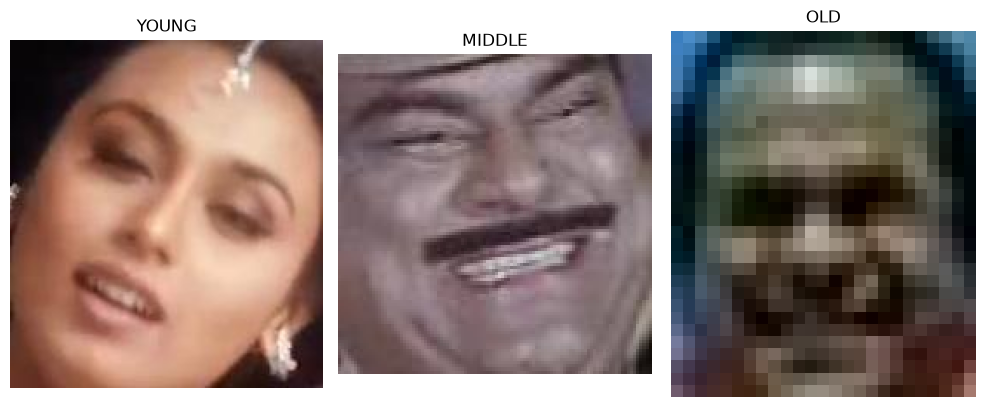

In [2]:
# sample image per class
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, cls in zip(axes, ["YOUNG", "MIDDLE", "OLD"]):
    row = df[df["Class"] == cls].sample(1, random_state=42).iloc[0]
    img = Image.open(os.path.join(IMG_DIR, row["ID"])).convert("RGB")
    ax.imshow(img); ax.set_title(cls); ax.axis("off")
plt.tight_layout(); plt.show()

## Part B: Preprocess the images

In [3]:
# imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms

# label map and image size
LABEL_MAP = {"YOUNG": 0, "MIDDLE": 1, "OLD": 2}
IMG_SIZE  = 128

# train transform with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# val transform — no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
# custom dataset class
class FaceAgeDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row["ID"])).convert("RGB")
        label = LABEL_MAP[row["Class"]]
        return self.transform(img), label

## Part C: Split and batch

In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 80/20 stratified split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Class"])
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

# dataset objects
train_dataset = FaceAgeDataset(train_df, IMG_DIR, train_transform)
val_dataset   = FaceAgeDataset(val_df,   IMG_DIR, val_transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

imgs, lbls = next(iter(train_loader))
print("Batch shape:", imgs.shape)

Train: 15924 | Val: 3982
Batch shape: torch.Size([32, 3, 128, 128])


## Part D: Build the CNN

In [6]:
import torch

# seed for reproducibility
torch.manual_seed(42)

# device setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)
print("Seed set: 42")

Device: mps


In [7]:
# CNN model
class AgeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # conv block: Conv-BN-ReLU-Conv-BN-ReLU-MaxPool
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2, 2))

        # 4 conv blocks
        self.features = nn.Sequential(
            block(3,   64),
            block(64,  128),
            block(128, 256),
            block(256, 512))

        # global average pooling + classifier
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.flatten    = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(self.pool(x))
        return self.classifier(x)

# create and verify model
model  = AgeCNN().to(device)
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")
print("Output shape:", model(torch.randn(4, 3, 128, 128).to(device)).shape)

Parameters: 4,819,395
Output shape: torch.Size([4, 3])


## Part E: Train and evaluate

In [8]:
import torch.optim as optim
from collections import Counter

# class weights for imbalance
counts  = Counter(df["Class"].map(LABEL_MAP))
weights = torch.tensor([len(df)/(3*counts[i]) for i in range(3)], dtype=torch.float).to(device)
print("Class weights:", [round(w.item(), 3) for w in weights])

# loss, optimizer, scheduler
loss_fn   = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

Class weights: [0.989, 0.614, 2.769]


In [9]:
# train one epoch
def train_epoch(loader):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = model(imgs)
        loss  = loss_fn(preds, lbls)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        loss_sum += loss.item() * len(imgs)
        correct  += (preds.argmax(1) == lbls).sum().item()
        total    += len(imgs)
    return loss_sum / total, correct / total

# evaluate
def evaluate(loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs)
            loss  = loss_fn(preds, lbls)
            loss_sum += loss.item() * len(imgs)
            correct  += (preds.argmax(1) == lbls).sum().item()
            total    += len(imgs)
    return loss_sum / total, correct / total

In [ ]:
# training loop
EPOCHS       = 30
best_val_acc = 0.0
history      = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(train_loader)
    vl_loss, vl_acc = evaluate(val_loader)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(vl_acc)

    # save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train {tr_acc*100:.1f}% {tr_loss:.4f} | Val {vl_acc*100:.1f}% {vl_loss:.4f}")

# load best weights and final accuracy
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
_, final_acc = evaluate(val_loader)
print(f"\nBest model loaded.")
print(f"Final Val Accuracy: {final_acc*100:.2f}%")

Epoch 01/30 | Train 36.8% 1.0902 | Val 40.5% 1.0533
Epoch 02/30 | Train 37.4% 1.0748 | Val 39.4% 1.0654
Epoch 03/30 | Train 36.4% 1.0756 | Val 41.9% 1.0717
Epoch 04/30 | Train 39.1% 1.0716 | Val 38.3% 1.0424
Epoch 05/30 | Train 40.8% 1.0806 | Val 48.1% 1.0675
Epoch 06/30 | Train 40.2% 1.0757 | Val 41.6% 1.0431
Epoch 07/30 | Train 39.9% 1.0643 | Val 47.6% 1.0117
Epoch 08/30 | Train 41.5% 1.0440 | Val 35.9% 1.0560
Epoch 09/30 | Train 40.8% 1.0267 | Val 48.1% 0.9852
Epoch 10/30 | Train 39.2% 1.0172 | Val 46.2% 0.9698
Epoch 11/30 | Train 41.3% 1.0031 | Val 39.3% 0.9977
Epoch 12/30 | Train 40.3% 1.0005 | Val 42.7% 0.9449
Epoch 13/30 | Train 40.3% 0.9873 | Val 45.5% 0.9606
Epoch 14/30 | Train 40.0% 0.9822 | Val 37.2% 1.1357
Epoch 15/30 | Train 40.7% 0.9756 | Val 44.2% 0.9476
Epoch 16/30 | Train 42.6% 0.9666 | Val 43.9% 0.9103
Epoch 17/30 | Train 44.1% 0.9585 | Val 56.7% 0.9430
Epoch 18/30 | Train 50.8% 0.9303 | Val 59.7% 0.8537
Epoch 19/30 | Train 55.1% 0.8943 | Val 63.0% 0.8386
Epoch 20/30 

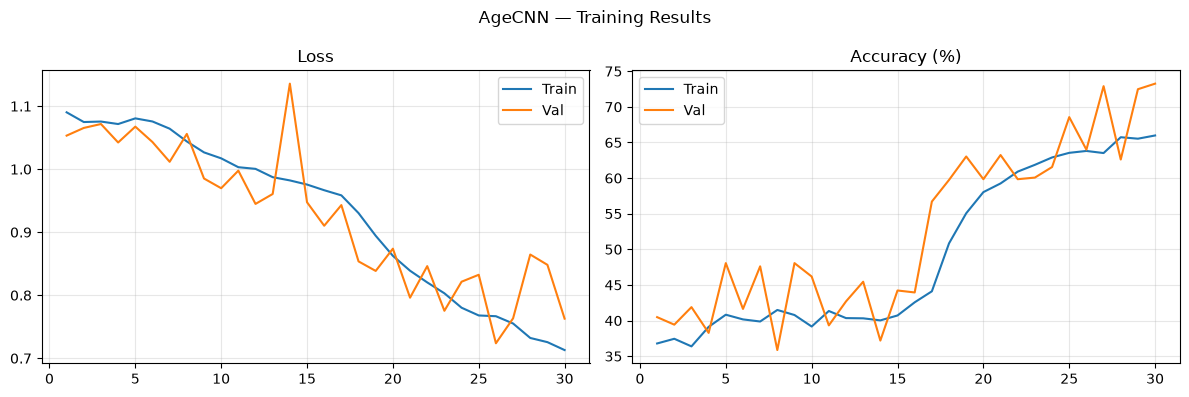

In [11]:
# plot loss and accuracy curves
ep = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, history["train_loss"], label="Train"); ax1.plot(ep, history["val_loss"], label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, [a*100 for a in history["train_acc"]], label="Train")
ax2.plot(ep, [a*100 for a in history["val_acc"]], label="Val")
ax2.set_title("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("AgeCNN — Training Results"); plt.tight_layout(); plt.show()